# Exploring the Dynamics of the Habit-Portfolio Model

The consumption-saving model with portfolio choice and habit formation is fairly novel, and thus the role of habit formation is not fully understood. This notebook presents some exercises that explore how model outcomes evolve in response to an unexpected shock, using an infinite horizon framework. While the model has more useful applications in a life-cycle setting, an infinite horizon model removes distractions through other mechanisms, allowing us to focus on the dynamics of one unexpected shock at a time.

In [1]:
from HARK.models import HabitPortfolioConsumerType, RiskyAssetConsumerType
from HARK.ConsumptionSaving.ConsHabitModel import (
    HabitPortfolioConsumerType_defaults,
)
from time import time
import numpy as np
import matplotlib.pyplot as plt

mystr = lambda x: "{:.3f}".format(x)

## Preliminary Setup: Baseline Agents

First, let's define a base parameter dictionary. We'll set risk aversion to be moderately high ($\rho=3.5$) so that our agents actually choose mixed portfolios. To focus on the dynamic response to shocks, we'll turn off mortality ($\mathsf{S} = 1$) so that changes over time reflect the behavior of survivors, rather than the arrival of replacement agents. Likewise, we turn off expected permanent income growth ($\Gamma = 1$) so that we don't have to offer any caveats about the figures representing detrended averages (or worse, plotting upward sloping "steady state" graphs).

The discount factor will be turned down slightly ($\beta = 0.94$) to partially compensate for these changes. The risk free rate is calibrated to $\mathsf{R} = 1.01$, while the risky asset has mean return of $1.04$ with an $18\%$ standard deviation of log returns. With these parameter choices, the absolute patience condition $(\beta R)^{1/\rho} < 1$ is satisfied *even if* the agents always invest fully in the risky asset. The absolute patience condition means that *eventually* the expected consumption growth factor is below 1, guaranteeing that consumption (and wealth) don't grow without bound. Without this condition, the ergodic distribution of wealth generated by our grid-based methods would be nonsensical, with a large point mass at the highest gridpoint (or even degenerate).

Because we will be experimenting with faster habit rates ($\lambda$), the top of the habit grid has to be set a bit higher; this prevents the solver from breaking near the terminal period.

In [2]:
# Make a parameter dictionary
my_params = HabitPortfolioConsumerType_defaults.copy()
del my_params["constructors"]  # don't want to overwrite these
adjusted_params = {
    "CRRA": 3.5,
    "LivPrb": [1.0],
    "DiscFac": 0.94,
    "PermGroFac": [1.0],
    "Rfree": [1.01],
    "RiskyAvg": 1.04,
    "RiskyStd": 0.18,
    "RiskyShareFixed": None,
    "hLogInitMean": 0.0,
    "HabitMax": 8.0,
    "HabitCount": 51,
    "cycles": 0,
}
my_params.update(adjusted_params)

T_sim = 200  # how many periods to simulate after the shock
T_pre = 20  # how many pre-periods to plot (at the long run value)

Next, we need to specify parameters for the discretized grids that we'll use for the simulation. Note that these grids aren't used to *solve* the model, but only when conducting the shock experiments. The parameters for each grid designate the top, bottom, number of gridpoints, and polynomial order for the spacing (higher order means they are more clustered near the bottom).

Note that there are *two* continuation/arrival state dimensions in the model with habit formation, so the beginning-of-period state grid has $201 \times 76 = 15276$ points. The *transition matrix* that advances the distribution of states by one period (accounting for risk realizations, policy functions, and intraperiod dynamics) is thus a whopping $15276 \times 15276$ in size, with over 233 million elements. Thank god for sparse matrices!

In [3]:
# Define grid specifications
wealth_grid = {"min": 0.0, "max": 120.0, "N": 201, "order": 2.5}
con_grid = {"min": 0.0, "max": 3.0, "N": 301, "order": 1.1}
share_grid = {"min": 0.0, "max": 1.0, "N": 101}
habit_grid = {"min": 0.3, "max": 3.0, "N": 76, "order": 2.0}
my_grids_base = {
    "kNrm": wealth_grid,
    "wNrm": wealth_grid,
    "qNrm": wealth_grid,
    "cNrm": con_grid,
    "Share": share_grid,
}
my_grids = my_grids_base.copy()
my_grids["hPre"] = habit_grid
my_grids["hNrm"] = habit_grid

As our baseline comparitor, let's use agents who allocate their portfolio between a risky and riskless asset, but who don't form consumption habits. In the cell below, we make a representation of these agents (with our chosen parameters), solve their infinite horizon model, and then build the transition matrix that represents how the distribution of beginning-of-period arrival variables evolves from one period to the next. That matrix will be used to "grid simulate" the distribution of states after we shock it from its long run distribution.

In [4]:
# Make and solve the base type with no habits
BaseType = RiskyAssetConsumerType(**my_params)
t0 = time()
BaseType.solve()
BaseType.initialize_sym()
BaseType._simulator.make_transition_matrices(my_grids_base, norm="PermShk")
BaseType._simulator.find_steady_state()
t1 = time()
print("Solving the model with no habits took " + mystr(t1 - t0) + " seconds.")

Solving the model with no habits took 3.580 seconds.


## Preliminary Setup: Defining Our Functions

In the experiments, we will perturb the long run steady state distribution by (say) halving everyone's asset or habit stock. This is accomplished using "grid simulation" methods that tracks the distribution of states on a discretized grid, resulting in much smoother results than would be achieved with finite sample Monte Carlo integration.

HARK's grid simulation method takes advantage of the "Harmenberg normalization trick," which allows us to forgo tracking the distribution of permanent income jointly with the other state variables. The stochastic vector that represents the distribution of states will actually measure the fraction of *permanent income* in the population that is at that gridpoint, rather than the fraction of *agents*. The true population average of *non-normalized* state variables (i.e. in level) can thus be recovered from this distribution, but plotting the distribution itself is *slightly* misleading.

The cell below defines the main function that is used in the experiments. It simply uses HARK's internal grid simulation methods to produce the time series of mean outcomes (for consumption, assets, risky asset share, and the habit stock) in response to a specified shock, and tacks on some periods at the steady state before the shock.

Because of the Harmenberg trick, the risky asset share has to be calculated differently. We report it as total wealth held in the risky asset divided by total wealth.

In [5]:
# Define a function that runs an MIT shock experiment using grid simulation
def run_MIT_shock_experiment(Agent, T_pre, T_sim, shock, habit=True):
    # Execute the MIT shock experiment
    my_vars = ["cNrm", "aNrm", "wNrm", "qNrm"]
    if habit:
        my_vars += ["hNrm"]
    Agent._simulator.simulate_shock_by_grids(my_vars, T_sim, shock)

    # Extract and return average sequences of assets, consumption, risky asset share, and habits
    C = np.concatenate(
        (
            np.full(T_pre, Agent._simulator.get_long_run_average("cNrm")),
            Agent._simulator.history_avg["cNrm"],
        )
    )
    A = np.concatenate(
        (
            np.full(T_pre, Agent._simulator.get_long_run_average("aNrm")),
            Agent._simulator.history_avg["aNrm"],
        )
    )
    W = np.concatenate(
        (
            np.full(T_pre, Agent._simulator.get_long_run_average("wNrm")),
            Agent._simulator.history_avg["wNrm"],
        )
    )
    Q = np.concatenate(
        (
            np.full(T_pre, Agent._simulator.get_long_run_average("qNrm")),
            Agent._simulator.history_avg["qNrm"],
        )
    )
    S = Q / W  # aggregate risky wealth share
    H = (
        np.concatenate(
            (
                np.full(T_pre, Agent._simulator.get_long_run_average("hNrm")),
                Agent._simulator.history_avg["hNrm"],
            )
        )
        if habit
        else np.ones(T_pre + T_sim)
    )

    return C, A, S, H

The experiments examine how some model parameters affect agent behavior, so we will be running the "MIT shock experiment" on several `AgentType` instances and comparing their output. The function in the cell below simply runs the same experiment on an arbitrary list of `AgentType`s and compiles the results into four lists.

In [6]:
# Define a function to run an experiment on several types and return lists
def run_experiment_on_types(Agents, T_pre, T_sim, shock):
    C_out = []
    A_out = []
    S_out = []
    H_out = []
    for Agent in Agents:
        habit = type(Agent) is HabitPortfolioConsumerType
        C, A, S, H = run_MIT_shock_experiment(Agent, T_pre, T_sim, shock, habit)
        C_out.append(C)
        A_out.append(A)
        S_out.append(S)
        H_out.append(H)
    return C_out, A_out, S_out, H_out

We're grid-simulating 200 periods post-shock, so we need to look at the results visually rather than numerically. The cell below defines a function that makes a plot comparing the time series of *one* outcome across several `AgentType`s with different parameters.

In [7]:
# Define a function to compare the results of experiments across types
def make_experiment_comparison_plot(X, T_pre, outcome, labels, desc):
    t_vec = np.arange(-T_pre, len(X[0]) - T_pre)
    for j in range(len(X)):
        plt.plot(t_vec, X[j], "-")
    plt.xlabel(r"time $t$")
    plt.ylabel(outcome)
    plt.title("Response to " + desc)
    plt.legend(labels, loc=(0.05, -0.2), ncols=4)
    plt.tight_layout()
    plt.show()

Finally, we have four outcomes, so the cell below makes a simple function to produce all four plots.

In [8]:
# Define a function to draw four comparison plots
def draw_four_plots(CASH, T0, labels, desc):
    make_experiment_comparison_plot(CASH[0], T0, r"Consumption $C_t$", labels, desc)
    make_experiment_comparison_plot(
        CASH[1], T0, r"End-of-period assets $A_t$", labels, desc
    )
    make_experiment_comparison_plot(
        CASH[2], T0, r"Risky asset share $s_t$", labels, desc
    )
    make_experiment_comparison_plot(CASH[3], T0, r"Habit stock $H_t$", labels, desc)

## The Role of Habit Weight $\alpha$

The habit formation model has two key new parameters relative to the standard portfolio-allocation model: habit weight $\alpha$ and habit rate $\lambda$. Let's experiment with what the "habit weight" parameter $\alpha$ does, using low, medium, and high values ($0.2, 0.5, 0.8$ respectively).

The cell below makes three `HabitPortfolioConsumerType` instances, gives them parameters, solves their model, and constructs the transition matrix for grid simulation. To make the time series easier to interpret, we have calibrated the discount factor $\beta$ and risk aversion $\rho$ for each type so that the long run average assets $A_t$ and risky asset share $s_t$ are (roughly) identical across types.

Notice that to maintain the same mean risky asset share (about 69%), agents with consumption habits need *significantly* higher risk aversion. That is, consumption habits make the agents *less risk averse* for any value of $\rho$, so $\rho$ needs to be increased to offset this. Gomes and Michaelides (2003) attribute this phenomenon to agents with consumption habits having higher intertemporal elasticity of substitution, but it can also be seen mathematically in the "permanent income normalization exponent" being scaled down by the factor $(1-\alpha)$.

Agents with a higher $\rho$ are very averse to consumption fluctuations (as are those with stronger habits), so they will tend to maintain a larger buffer stock of wealth to absorb income and return risks-- they don't want uncertainty to pass through to their consumption. Thus to maintain the same average assets $A_t$, agents with strong habits need to be *somewhat* more impatient. Our baseline calibration (with $\alpha=0$) has $\beta=0.94$, and even with strong habits of $\alpha=0.8$, the discount factor need only fall to $\beta=0.936$. But for low and medium habits, the calibrated discount factor turns out to be little changed from the baseline.

In [9]:
# Make and solve agents with low, medium, and high habits
alpha_list = [0.2, 0.5, 0.8]
beta_list = [0.9407, 0.9400, 0.9364]
rho_list = [3.890, 4.792, 5.927]
HabitTypes = []
for j in range(len(alpha_list)):
    t0 = time()
    temp_params = my_params.copy()
    temp_params["HabitWgt"] = alpha_list[j]
    temp_params["DiscFac"] = beta_list[j]
    temp_params["CRRA"] = rho_list[j]
    NewType = HabitPortfolioConsumerType(**temp_params)
    NewType.solve()
    NewType.initialize_sym()
    NewType._simulator.make_transition_matrices(my_grids, norm="PermShk")
    NewType._simulator.find_steady_state()
    HabitTypes.append(NewType)
    t1 = time()
    print(
        "Solving the habit type with alpha="
        + str(alpha_list[j])
        + " took "
        + mystr(t1 - t0)
        + " seconds."
    )

Solving the habit type with alpha=0.2 took 88.752 seconds.


Solving the habit type with alpha=0.5 took 55.045 seconds.


Solving the habit type with alpha=0.8 took 38.966 seconds.


In [10]:
# Define type labels
my_agents = [BaseType] + HabitTypes
type_labels = [r"$\alpha=0$"]
for j in range(len(alpha_list)):
    type_labels.append(r"$\alpha$=" + str(alpha_list[j]))

Now that we have each `AgentType`'s model characterized by a long run distribution of states and a transition matrix that describes how the current distribution of states evolves each period, running an "MIT shock experiment" is very low cost.

### The role of habit weight $\alpha$ in response to a large wealth shock

For the first experiment, let's imagine that *everyone's* end-of-period assets are unexpectedly *cut in half*. How do agents with different habit weight $\alpha$ values respond?

In [11]:
# Run an experiment in which wealth is shocked downward by 50%
t0 = time()
CASH_neg_wealth = run_experiment_on_types(my_agents, T_pre, T_sim, "aNrm * 0.5")
t1 = time()
print("The negative wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative wealth shock experiment took 27.491 seconds.


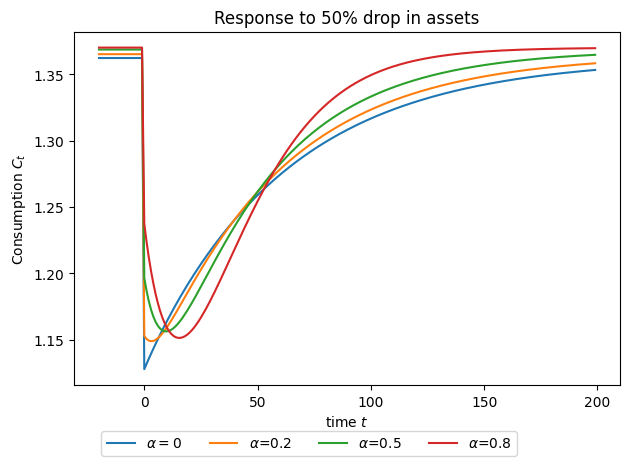

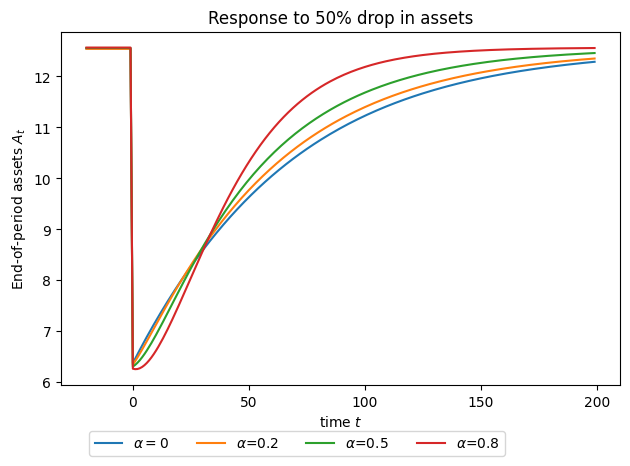

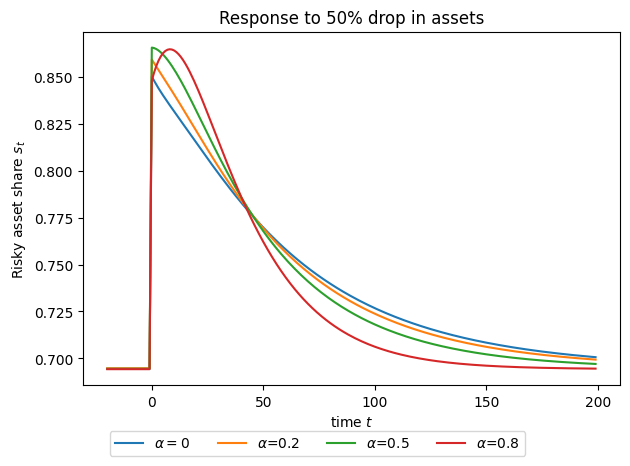

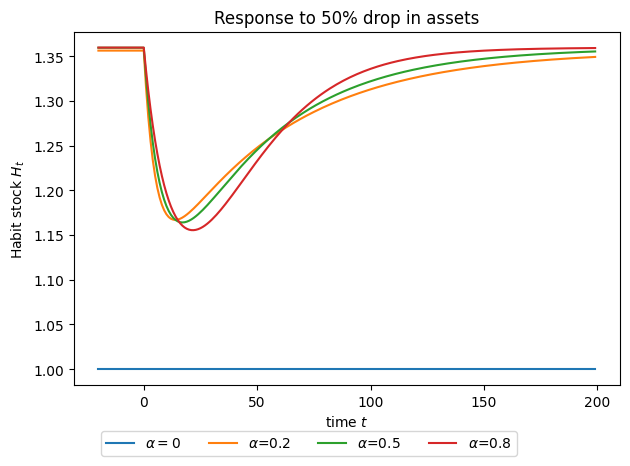

In [12]:
# Plot the results of the negative wealth shock experiment
draw_four_plots(CASH_neg_wealth, T_pre, type_labels, "50% drop in assets")

First, notice that even though long run average assets and risky asset share are identical across these four specifications, there are small but visible differences in long run average consumption and habit stock. Even though the *average* states are the same, both the distribution of states *and* the consumption function differ with $\alpha$, so the non-targets average values will differ across models.

The first plot shows (unsurprisingly) that agents with stronger habits (higher $\alpha$) cut their consumption by *less* in response to a large drop in wealth. Moreover, stronger habits induce agents to *continue* reducing consumption even after the shock: they know they need to spend less to recover to their target wealth, but they can't do it all at once. This effect is most pronounced for the model with the strongest habits (red, $\alpha = 0.8$).

In the second figure, we see that the agents with the strongest habits cut their consumption slowly enough that their assets don't even *begin* to recover in the first few periods, instead falling slightly for two more periods. However, the ongoing consumption reduction quickly reverses this trend, and the assets of the $\alpha = 0.8$ type eventually recover *faster* than those with weaker (or no) habits. Even though the wealth of the strong habit type overtakes the other types around $t=35$, their *consumption* doesn't catch up until later, after $t=35$. The additional periods with lower consumption help their wealth (and spending) return to the long run level *even faster*.

Moreover, after a slightly smaller initial jump in their risky asset share, the agents with the strongest habits *continue* to invest more in equities over the next few periods; by $t=10$, they put significantly more of their wealth into the risky asset than the lower (or no) habit types. This is partly mechanical, as the risky share function is (mostly) downward sloping in wealth, so we should expect to see a higher allocation to equities. However, the strongest habit type continues to hold a riskier portfolio for some time even after their wealth has caught up to the other types. Generally, stronger habits are associated with more willingness to hold risky assets, which Gomes and Michaelides attribute to the higher intertemporal elasticity of substitution in the presence of consumption habits.

Finally, the last figure shows that the habit stock is slower to adjust downward *and* to recover for stronger habits. This is due to the *choices* of the agents described above, with strong habit consumers being slower to adjust their behavior, rather than a mechanical effect of habits themselves. In contrast, the speed of updating of habits *is* mechanically governed by $\lambda$, which is explored below.

**NB:** The "habit stock" for the type with $\alpha=0$ is arbitrarily plotted at $1.0$. Because we used `RiskyAssetConsumerType`, the habit stock *does not exist* in the model and simulation. If we instead used `HabitPortfolioConsumerType` with `HabitWgt = 0.0`, then the blue habit time series would evolve as expected (but have no effect).

### The role of habit weight $\alpha$ in response to a large habit shock

Now let's suppose that *everyone's* end-of-period habit stock is unexpectedly *cut in half*. This isn't something with a real world analogue or that can actually happen; it's just for the sake of exploration. How would agents with different habit weight $\alpha$ values respond?

In [13]:
# Run an experiment in which the habit stock is shocked downward by 50%
t0 = time()
CASH_neg_habit = run_experiment_on_types(my_agents[1:], T_pre, T_sim, "HNrm * 0.5")
t1 = time()
print("The negative habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative habit shock experiment took 28.693 seconds.


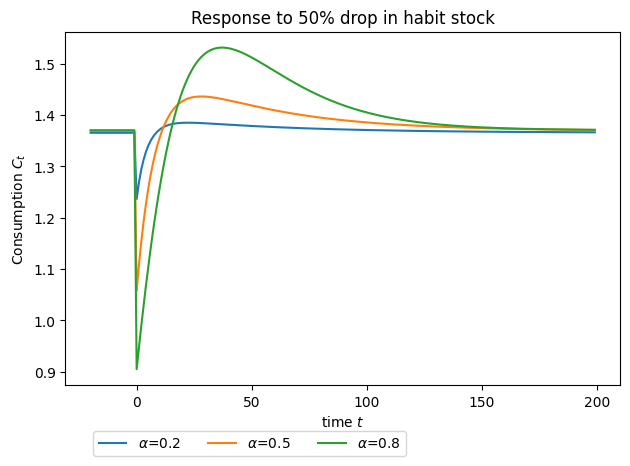

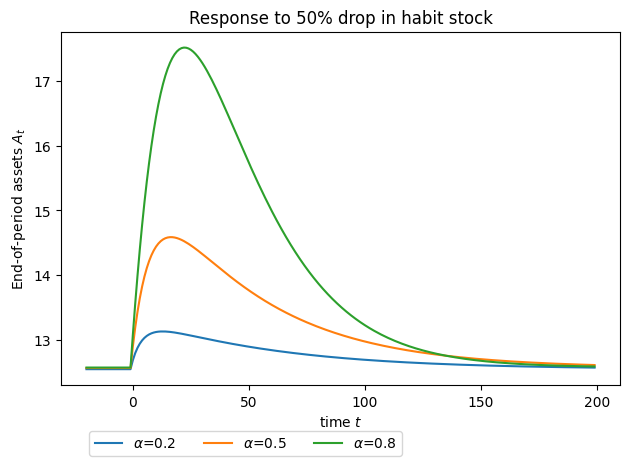

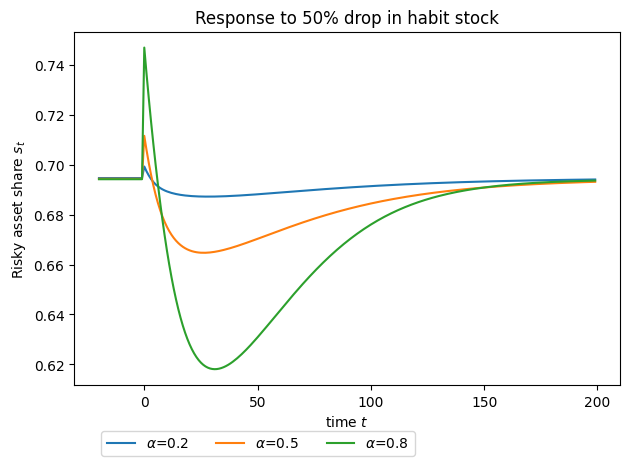

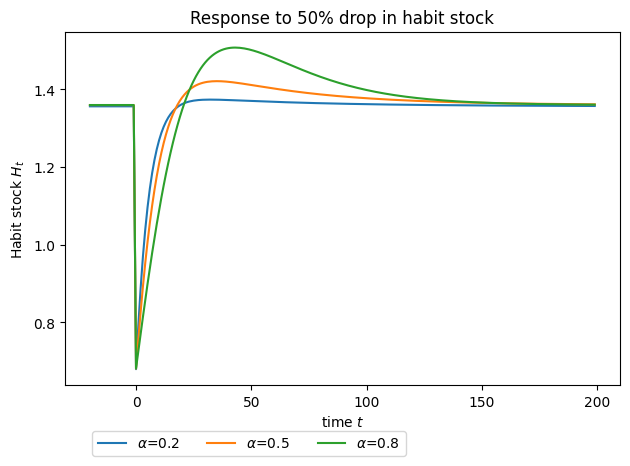

In [14]:
# Plot the results of the negative habit shock experiment
draw_four_plots(CASH_neg_habit, T_pre, type_labels[1:], "50% drop in habit stock")

**NB:** The colors have changed for these plots compared to the wealth shock experiment because the $\alpha=0$ type is excluded.

If the habit stock drops suddenly, all agents with habits want to cut their consumption, but those with the strongest habits want to cut their consumption by the most. This occurs due to a forward-looking effect. Recall that the expression inside the CRRA utility function can be rearranged as a Cobb-Douglas combination of current consumption (weight $1-\alpha$) and the consumption-habit ratio (weight $\alpha$). When the habit stock is low, consumers with habits foresee that they have an opportunity to have a high consumption-habit ratio for a while. Because they have convex preferences (concave utility), the agents do *not* want to concentrate all of the high growth rate into a small window of time; they achieve more utility from spreading it out among many periods, and this effect is stronger for agents with higher $\alpha$.

Consequently, agents with the strongest habits want to cut their consumption by the most in response to a downward shock to their habit stock. This allows them to have *more periods* with high $c_t / h_t$, which they value very strongly. Moreover, they run up a very large stockpile of wealth from the initial cut to consumption, and eventually begin consuming from it to return to long run average wealth. Agents with moderate and strong habits acquire so much wealth that their consumption rises substantially above the long run average. Agents with the strongest habits take the longest to run down this initial wealth because they need to spread out the periods with *low* $c_t / h_t$ (because their consumption is falling as they return to normal).

The dynamics of the risky asset share are largely mechanical: when the moderate and strong habit types run up large wealth, their allocation to equities falls because of the generally downward sloping risky share policy function, then slowly returns to the long run average as they run down their accumulated wealth. Note that the initial jump in risky asset share is *larger* for strong habit types, indicating that portfolio allocation is more sensitive to the habit stock when habits are strong.

## The Role of Habit Rate $\lambda$

Now let's experiment with the "habit rate" parameter $\lambda$. We'll use the "strong habits" type ($\alpha = 0.8$) as the base. At the top of this notebook, we set $\lambda = 0.2$ for the prior experiment. Let's try a faster rate and a slower rate and run the same experiments as before.

Once again, we calibrate $\beta$ and $\rho$ so that each `AgentType` has (roughly) the same long run average assets and risky asset share. As it turns out, *fast-evolving* habits also require higher risk aversion to generate the same average portfolio shares ($\lambda = 0.3$ has $\rho = 10.6$ compared to $\rho = 9.7$ for $\lambda=0.2$), but the discount factor changes very little.

In [15]:
# Make and solve agents with habits that evolve faster or slower
lambda_list = [0.1, 0.3]
beta_list_alt = [0.9373, 0.9329]
rho_list_alt = [4.699, 7.017]
HabitTypesAlt = []
for j in range(len(lambda_list)):
    t0 = time()
    temp_params = my_params.copy()
    temp_params["HabitWgt"] = alpha_list[-1]  # use strongest habit
    temp_params["HabitRte"] = lambda_list[j]
    temp_params["DiscFac"] = beta_list_alt[j]
    temp_params["CRRA"] = rho_list_alt[j]
    NewType = HabitPortfolioConsumerType(**temp_params)
    NewType.solve()
    NewType.initialize_sym()
    NewType._simulator.make_transition_matrices(my_grids, norm="PermShk")
    NewType._simulator.find_steady_state()
    HabitTypesAlt.append(NewType)
    t1 = time()
    print(
        "Solving the habit type with lambda="
        + mystr(lambda_list[j])
        + " took "
        + mystr(t1 - t0)
        + " seconds."
    )

Solving the habit type with lambda=0.100 took 43.956 seconds.


Solving the habit type with lambda=0.300 took 43.952 seconds.


In [16]:
# Define type labels
my_agents_alt = [HabitTypesAlt[0], HabitTypes[-1], HabitTypesAlt[-1]]
type_labels_alt = []
for j in range(len(my_agents_alt)):
    type_labels_alt.append(r"$\lambda$=" + str(my_agents_alt[j].HabitRte))

### The role of habit rate $\lambda$ in response to a large wealth shock

As we did before, let's imagine that *everyone's* end-of-period assets are unexpectedly *cut in half*. How do agents with different habit rate $\lambda$ values respond?

In [17]:
# Run an experiment in which wealth is shocked downward by 50%
t0 = time()
CASH_neg_wealth_alt = run_experiment_on_types(my_agents_alt, T_pre, T_sim, "aNrm * 0.5")
t1 = time()
print("The negative wealth shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative wealth shock experiment took 26.496 seconds.


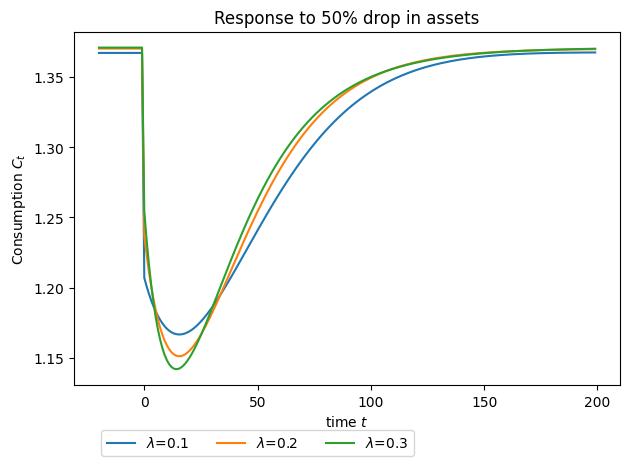

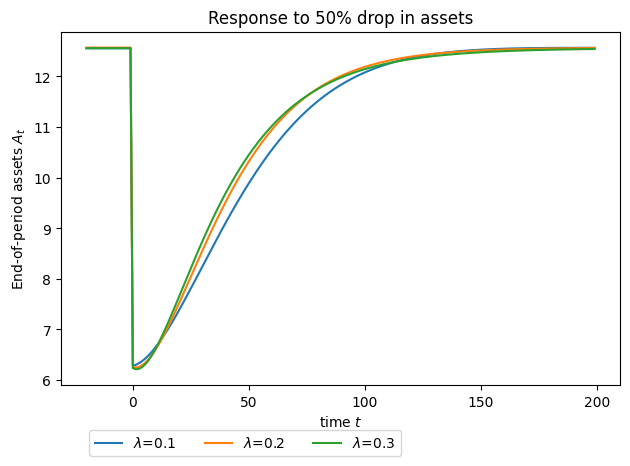

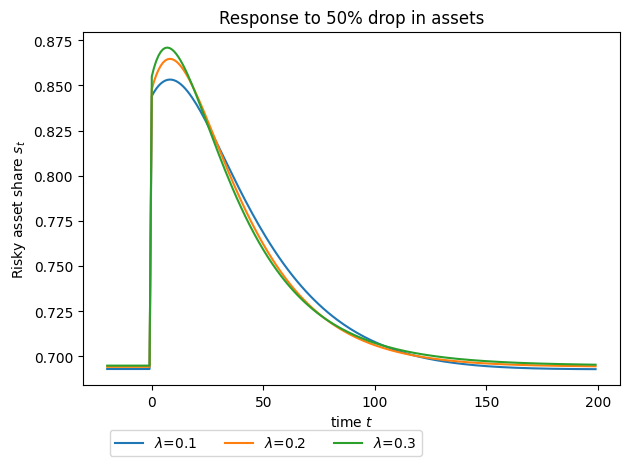

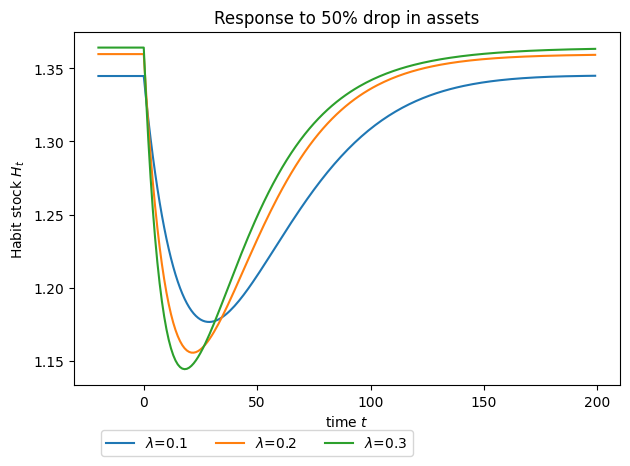

In [18]:
# Plot the results of the negative wealth shock experiment
draw_four_plots(CASH_neg_wealth_alt, T_pre, type_labels_alt, "50% drop in assets")

THIS ANALYSIS IS IN PROCESS

### The role of habit rate $\lambda$ in response to a large habit shock

Now suppose that *everyone's* end-of-period habit stock is unexpectedly *cut in half*. How do agents with different habit rate $\lambda$ values respond? Again, this is an "impossible shock" that has no real world equivalent-- it can't happen to real people.

In [19]:
# Run an experiment in which the habit stock is shocked downward by 50%
t0 = time()
CASH_neg_habit_alt = run_experiment_on_types(my_agents_alt, T_pre, T_sim, "HNrm * 0.5")
t1 = time()
print("The negative habit shock experiment took " + mystr(t1 - t0) + " seconds.")

The negative habit shock experiment took 25.762 seconds.


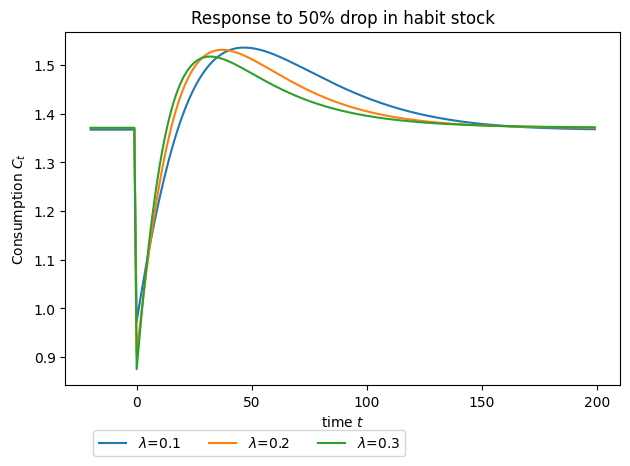

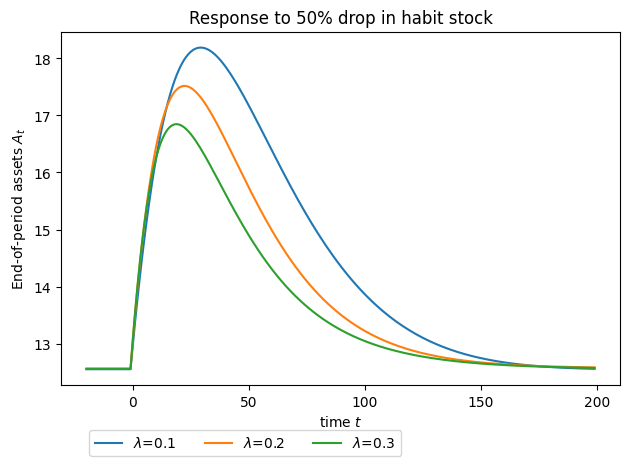

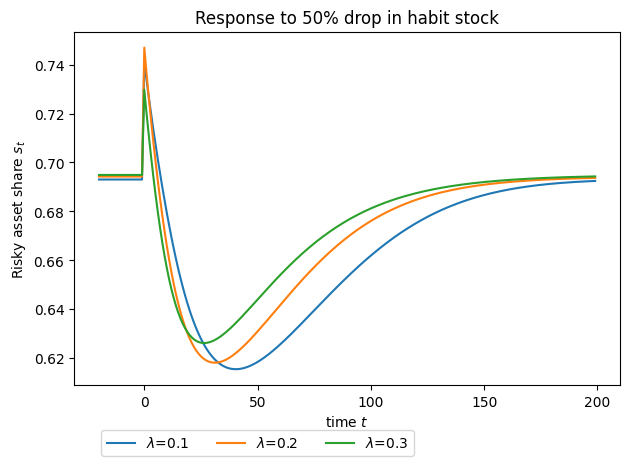

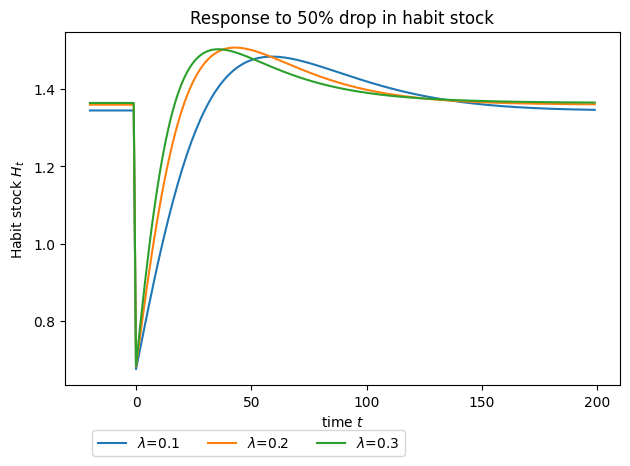

In [20]:
# Plot the results of the negative habit shock experiment
draw_four_plots(CASH_neg_habit_alt, T_pre, type_labels_alt, "50% drop in habit stock")

If the habit stock were to suddenly drop, agents with habits want to cut their consumption immediately, as described above. Agents with *slow* habits foresee that they have *more* periods to enjoy their lower habit stock, and can "play the long game". They consequently don't cut consumption by quite as much as those with faster habits (but the difference is slight). More importantly, their consumption *growth* is slower in the subsequent periods (shallower slope). That is, agents with slow-adapting habits spread out their high $c_t / h_t$ periods over a longer period of time because they know that $h_t$ is slow to adjust.

Thus while asset accumulation is very similar among the three types through about $t=10$ or $t=15$, the slow habit type *continues* to run up their wealth for significantly longer. Even with slow consumption growth, the blue consumption curve eventually overtakes the yellow and green curves. Moreover, the slow habit agents also spread out the consumption *decline* among a longer span of time, with a shallower return to the long run average.

The dynamic effects of the habit shock on risky asset share appear to be mostly mechanical, rather than arising from a strong effect of $\lambda$ on the risky share policy function. That is, the initial jump in risky share is similar among all three types, and the subsequent path (falling before leveling out and then rising back to the long run level) follows the same pattern we would expect from the wealth paths of the three types. Notice that the trough of the $s_t$ plot for each type happens at almost the same time as its peak for assets.

Finally, the time series of average habit stock has no surprises. The types start from similar (but not identical levels), and mechanically drop to almost the same level. The $\lambda=0.1$ type naturally recovers its habit stock more slowly than the other types, and even though it has noticeably higher consumption from $t=45$ onward, its habit stock is only barely above the slower types.